# Notebook 04 — Cut Edge Detection via Gap Boundary Analysis

**Pipeline:** Adaptive Classical Vision Pipeline for Cut-Edge Detection  
**Step 4:** Rubber mask + edge map → detect gaps → extract precise border pairs → sample points

**Input:**
- Clean rubber masks from `outputs/03_canny/debug/clean_masks/`
- Edge maps from `outputs/03_canny/`
- Calibration from `outputs/02_rectified/calibration.json`

**Output:** `outputs/04_hough/lines.json`

**Strategy:**
1. Detect dominant orientation of rubber bands (horizontal or vertical)
2. Find gaps between rubber segments (white regions between black rubber)
3. For each gap, use the Canny edge map to extract the two precise border lines
4. Sample 10 points along each border
5. Save borders and sample points for NB05

## 1. Imports and configuration

In [1]:
!pip install opencv-python numpy matplotlib scipy

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path
from scipy.ndimage import label as scipy_label

In [3]:
# ── Paths ──────────────────────────────────────────────────────────────────
MASKS_DIR     = Path("outputs/03_canny/debug/clean_masks")  # from NB03
CANNY_DIR     = Path("outputs/03_canny")                     # edge maps from NB03
CALIB_PATH    = Path("outputs/02_rectified/calibration.json")
OUTPUT_DIR    = Path("outputs/04_hough")
DEBUG_DIR     = OUTPUT_DIR / "debug"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DEBUG_DIR.mkdir(parents=True, exist_ok=True)

# ── Gap detection parameters ───────────────────────────────────────────────
# Minimum fraction of background pixels in a column/row to consider it a gap
GAP_BG_RATIO      = 0.3

# Minimum width of a gap in pixels
MIN_GAP_WIDTH_PX  = 3

# Maximum width of a gap in pixels (avoids detecting the space between two bands)
MAX_GAP_WIDTH_PX  = 80

# Minimum length of a gap (in the perpendicular direction) to be considered valid
MIN_GAP_LENGTH_PX = 100

# ── Border extraction parameters ───────────────────────────────────────────
# Search window around each gap edge to find Canny edge pixels
BORDER_SEARCH_WIDTH = 15   # px on each side of the gap boundary

# Minimum number of edge pixels needed to consider a border valid
MIN_EDGE_PIXELS = 20

# ── Sampling parameters ────────────────────────────────────────────────────
N_SAMPLE_POINTS = 10

# ── Dataset filtering ──────────────────────────────────────────────────────
VALID_EXTENSIONS = {".jpg", ".jpeg", ".png"}
DATASET_PREFIX   = "Multimedia_"

# Load calibration
with open(CALIB_PATH) as f:
    calibration_data = json.load(f)

print(f"Masks dir        : {MASKS_DIR.resolve()}")
print(f"Canny dir        : {CANNY_DIR.resolve()}")
print(f"Output dir       : {OUTPUT_DIR.resolve()}")
print(f"Calibrated images: {len(calibration_data)}")

Masks dir        : C:\Users\david\OneDrive\Documentos\UNI\VISION ARTIFICIAL\VA_RetoMichelin\models\David\outputs\03_canny\debug\clean_masks
Canny dir        : C:\Users\david\OneDrive\Documentos\UNI\VISION ARTIFICIAL\VA_RetoMichelin\models\David\outputs\03_canny
Output dir       : C:\Users\david\OneDrive\Documentos\UNI\VISION ARTIFICIAL\VA_RetoMichelin\models\David\outputs\04_hough
Calibrated images: 20


## 2. Orientation detection

Determine if rubber bands run horizontally or vertically by comparing
the variance of column-wise vs row-wise background projections.

In [4]:
def detect_orientation(mask: np.ndarray) -> str:
    """
    Detect dominant orientation of rubber bands.

    If bands run horizontally → gaps are vertical → returns 'vertical'
    If bands run vertically   → gaps are horizontal → returns 'horizontal'

    Strategy: compute background fraction per column and per row.
    Higher variance means gaps are more clearly visible in that direction.
    """
    bg = (mask == 0).astype(np.float32)  # background = 0 in mask

    col_bg = bg.mean(axis=0)  # background fraction per column
    row_bg = bg.mean(axis=1)  # background fraction per row

    var_col = np.var(col_bg)
    var_row = np.var(row_bg)

    # High column variance → columns alternate rubber/gap → gaps are vertical
    if var_col >= var_row:
        return 'vertical'
    else:
        return 'horizontal'

## 3. Gap detection

Find the gaps between rubber segments by projecting the mask.
A gap is a run of columns (vertical gap) or rows (horizontal gap)
where the background fraction exceeds GAP_BG_RATIO.

In [5]:
def find_gaps(mask: np.ndarray, orientation: str) -> list[dict]:
    """
    Find gaps between rubber segments.

    Parameters
    ----------
    mask        : binary mask (255 = rubber, 0 = background)
    orientation : 'vertical' (gaps are columns) or 'horizontal' (gaps are rows)

    Returns
    -------
    gaps : list of dicts with:
        - start : first index of gap (column or row)
        - end   : last index of gap
        - center: center index
        - width : number of gap columns/rows
    """
    H, W = mask.shape
    bg   = (mask == 0).astype(np.float32)

    if orientation == 'vertical':
        projection = bg.mean(axis=0)   # per column
        length     = H
    else:
        projection = bg.mean(axis=1)   # per row
        length     = W

    # Binary: is this column/row a gap?
    is_gap = projection >= GAP_BG_RATIO

    # Find contiguous runs of gap columns/rows
    gaps = []
    in_gap = False
    gap_start = 0

    for i, g in enumerate(is_gap):
        if g and not in_gap:
            in_gap    = True
            gap_start = i
        elif not g and in_gap:
            in_gap   = False
            gap_width = i - gap_start
            if MIN_GAP_WIDTH_PX <= gap_width <= MAX_GAP_WIDTH_PX:
                gaps.append({
                    'start' : gap_start,
                    'end'   : i - 1,
                    'center': (gap_start + i - 1) // 2,
                    'width' : gap_width
                })

    # Close last gap if image ends in a gap
    if in_gap:
        gap_width = len(is_gap) - gap_start
        if MIN_GAP_WIDTH_PX <= gap_width <= MAX_GAP_WIDTH_PX:
            gaps.append({
                'start' : gap_start,
                'end'   : len(is_gap) - 1,
                'center': (gap_start + len(is_gap) - 1) // 2,
                'width' : gap_width
            })

    # Filter gaps that are too short in the perpendicular direction
    valid_gaps = []
    for gap in gaps:
        if orientation == 'vertical':
            gap_region = bg[:, gap['start']:gap['end']+1]
        else:
            gap_region = bg[gap['start']:gap['end']+1, :]

        # Check length: how many rows/cols have significant background
        perp_profile = gap_region.mean(axis=1 if orientation == 'vertical' else 0)
        gap_length   = np.sum(perp_profile > 0.3)

        if gap_length >= MIN_GAP_LENGTH_PX:
            gap['length'] = int(gap_length)
            valid_gaps.append(gap)

    return valid_gaps

## 4. Border extraction

For each gap, extract the two precise border lines using the Canny edge map.
We search within a window around each side of the gap for edge pixels,
then fit a representative profile.

In [6]:
def extract_border_points(edges: np.ndarray, gap: dict,
                           orientation: str, side: str) -> list[tuple]:
    """
    Extract precise border points from the Canny edge map for one side of a gap.

    Parameters
    ----------
    edges       : Canny edge map (binary)
    gap         : gap dict with start/end/center
    orientation : 'vertical' or 'horizontal'
    side        : 'left'/'right' for vertical gaps, 'top'/'bottom' for horizontal

    Returns
    -------
    points : list of (x, y) pixel coordinates of border edge pixels
    """
    H, W = edges.shape

    if orientation == 'vertical':
        if side == 'left':
            col_start = max(0, gap['start'] - BORDER_SEARCH_WIDTH)
            col_end   = gap['start'] + BORDER_SEARCH_WIDTH
        else:  # right
            col_start = gap['end'] - BORDER_SEARCH_WIDTH
            col_end   = min(W, gap['end'] + BORDER_SEARCH_WIDTH)

        col_start = max(0, col_start)
        col_end   = min(W, col_end)

        region = edges[:, col_start:col_end]
        ys, xs_rel = np.where(region > 0)
        xs = xs_rel + col_start

        return list(zip(xs.tolist(), ys.tolist()))

    else:  # horizontal
        if side == 'top':
            row_start = max(0, gap['start'] - BORDER_SEARCH_WIDTH)
            row_end   = gap['start'] + BORDER_SEARCH_WIDTH
        else:  # bottom
            row_start = gap['end'] - BORDER_SEARCH_WIDTH
            row_end   = min(H, gap['end'] + BORDER_SEARCH_WIDTH)

        row_start = max(0, row_start)
        row_end   = min(H, row_end)

        region = edges[row_start:row_end, :]
        ys_rel, xs = np.where(region > 0)
        ys = ys_rel + row_start

        return list(zip(xs.tolist(), ys.tolist()))


def fit_border_line(points: list[tuple], orientation: str,
                    img_shape: tuple) -> list[tuple] | None:
    """
    Fit a representative line through border edge points.

    For vertical borders: for each row, take the median x of edge pixels.
    For horizontal borders: for each column, take the median y of edge pixels.

    Returns a list of (x, y) points, one per row/column.
    """
    if len(points) < MIN_EDGE_PIXELS:
        return None

    H, W = img_shape
    pts  = np.array(points)

    if orientation == 'vertical':
        # Group by row (y), take median x per row
        result = []
        for y in range(H):
            xs_at_y = pts[pts[:, 1] == y, 0]
            if len(xs_at_y) > 0:
                result.append((int(np.median(xs_at_y)), int(y)))
        return result if len(result) >= MIN_EDGE_PIXELS else None

    else:  # horizontal
        # Group by column (x), take median y per column
        result = []
        for x in range(W):
            ys_at_x = pts[pts[:, 0] == x, 1]
            if len(ys_at_x) > 0:
                result.append((int(x), int(np.median(ys_at_x))))
        return result if len(result) >= MIN_EDGE_PIXELS else None

## 5. Sample points extraction

Extract N equally spaced sample points along each border line.

In [7]:
def sample_border_points(border_pts: list[tuple],
                          n: int = N_SAMPLE_POINTS) -> list[tuple]:
    """
    Extract n equally spaced points along a border.

    Parameters
    ----------
    border_pts : list of (x, y) sorted along the border
    n          : number of sample points

    Returns
    -------
    samples : list of n (x, y) tuples
    """
    if len(border_pts) < n:
        return border_pts

    indices = np.linspace(0, len(border_pts) - 1, n, dtype=int)
    return [border_pts[i] for i in indices]

## 6. Full pipeline per image

In [8]:
def process_image(image_name: str) -> dict | None:
    stem = Path(image_name).stem

    # Load mask from NB03 debug output
    mask_path = MASKS_DIR / f"{stem}_clean_mask.png"
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        print(f"  [SKIP] No mask found: {mask_path}")
        return None

    # Load edge map from NB03
    edges = cv2.imread(str(CANNY_DIR / image_name), cv2.IMREAD_GRAYSCALE)
    if edges is None:
        print(f"  [SKIP] No edge map found: {image_name}")
        return None

    H, W = mask.shape

    # Step 1: detect orientation
    orientation = detect_orientation(mask)

    # Step 2: find gaps
    gaps = find_gaps(mask, orientation)

    if not gaps:
        print(f"  [WARN] {image_name}: no gaps found (orientation={orientation})")
        return {
            'image_name'   : image_name,
            'orientation'  : orientation,
            'n_gaps'       : 0,
            'cut_edges_px' : [],
            'gap_borders'  : []
        }

    # Step 3: for each gap, extract both border lines
    side_a = 'left'  if orientation == 'vertical' else 'top'
    side_b = 'right' if orientation == 'vertical' else 'bottom'

    gap_borders = []
    cut_edges   = []  # flat list of [x1,y1,x2,y2] for compatibility with NB05

    for gap in gaps:
        pts_a_raw = extract_border_points(edges, gap, orientation, side_a)
        pts_b_raw = extract_border_points(edges, gap, orientation, side_b)

        border_a = fit_border_line(pts_a_raw, orientation, (H, W))
        border_b = fit_border_line(pts_b_raw, orientation, (H, W))

        if border_a is None or border_b is None:
            continue

        samples_a = sample_border_points(border_a)
        samples_b = sample_border_points(border_b)

        gap_borders.append({
            'gap'           : gap,
            'border_a_side' : side_a,
            'border_b_side' : side_b,
            'border_a_pts'  : samples_a,
            'border_b_pts'  : samples_b,
        })

        # Add both borders as cut edges for NB05
        if samples_a:
            cut_edges.append([samples_a[0][0],  samples_a[0][1],
                               samples_a[-1][0], samples_a[-1][1]])
        if samples_b:
            cut_edges.append([samples_b[0][0],  samples_b[0][1],
                               samples_b[-1][0], samples_b[-1][1]])

    return {
        'image_name'   : image_name,
        'orientation'  : orientation,
        'n_gaps'       : len(gap_borders),
        'cut_edges_px' : cut_edges,
        'gap_borders'  : gap_borders
    }

In [9]:
image_names = sorted([
    name for name in calibration_data.keys()
    if Path(name).suffix.lower() in VALID_EXTENSIONS
    and Path(name).name.startswith(DATASET_PREFIX)
])

print(f"Found {len(image_names)} images\n")

hough_results = {}

for image_name in image_names:
    result = process_image(image_name)
    if result is not None:
        hough_results[image_name] = result
        flag = "✓" if result['n_gaps'] == 2 else "✗"
        print(f"  [{flag}] {image_name:30s}  "
              f"orient={result['orientation']:10s}  "
              f"gaps={result['n_gaps']}  "
              f"edges={len(result['cut_edges_px'])}")

correct = sum(1 for r in hough_results.values() if r['n_gaps'] == 2)
print(f"\nCorrect (2 gaps): {correct} / {len(hough_results)} images")

# Save for NB05 and NB06
with open(OUTPUT_DIR / "lines.json", "w") as f:
    json.dump(hough_results, f, indent=2)
print(f"Saved to {OUTPUT_DIR / 'lines.json'}")

Found 20 images

  [WARN] Multimedia_31.jpg: no gaps found (orientation=horizontal)
  [✗] Multimedia_31.jpg               orient=horizontal  gaps=0  edges=0
  [WARN] Multimedia_32.jpg: no gaps found (orientation=horizontal)
  [✗] Multimedia_32.jpg               orient=horizontal  gaps=0  edges=0
  [WARN] Multimedia_33.jpg: no gaps found (orientation=horizontal)
  [✗] Multimedia_33.jpg               orient=horizontal  gaps=0  edges=0
  [WARN] Multimedia_34.jpg: no gaps found (orientation=horizontal)
  [✗] Multimedia_34.jpg               orient=horizontal  gaps=0  edges=0
  [WARN] Multimedia_35.jpg: no gaps found (orientation=vertical)
  [✗] Multimedia_35.jpg               orient=vertical    gaps=0  edges=0
  [WARN] Multimedia_36.jpg: no gaps found (orientation=vertical)
  [✗] Multimedia_36.jpg               orient=vertical    gaps=0  edges=0
  [WARN] Multimedia_37.jpg: no gaps found (orientation=vertical)
  [✗] Multimedia_37.jpg               orient=vertical    gaps=0  edges=0
  [WARN] 

## 7. Visual inspection

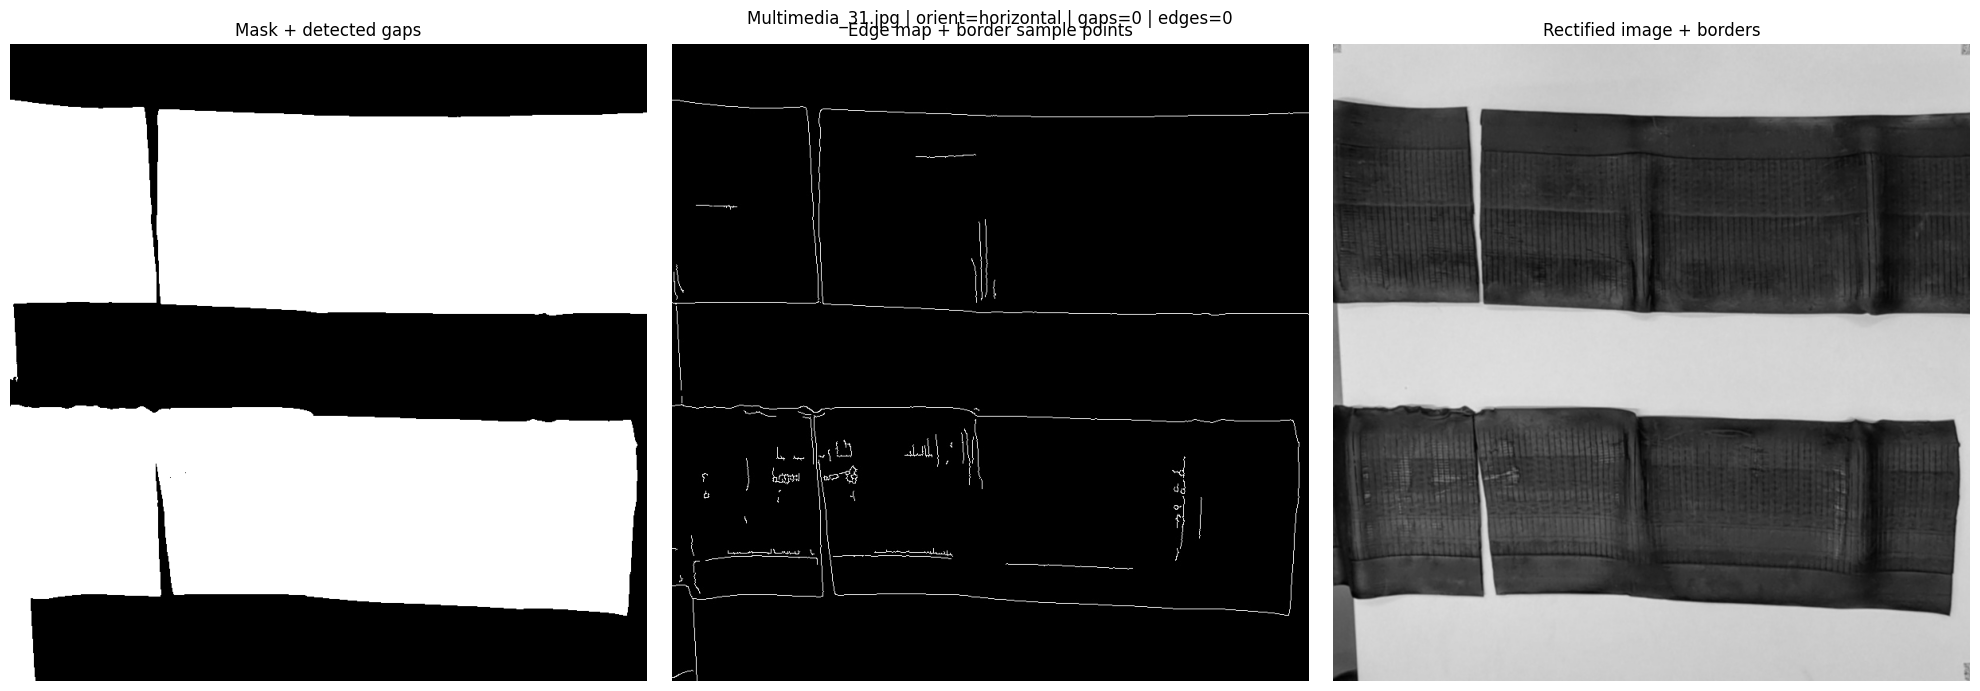

In [10]:
def visualize_result(image_name: str):
    if image_name not in hough_results:
        print(f"Not found: {image_name}")
        return

    result = hough_results[image_name]
    stem   = Path(image_name).stem

    mask  = cv2.imread(str(MASKS_DIR / f"{stem}_clean_mask.png"), cv2.IMREAD_GRAYSCALE)
    edges = cv2.imread(str(CANNY_DIR / image_name), cv2.IMREAD_GRAYSCALE)

    fig, axes = plt.subplots(1, 3, figsize=(20, 7))
    fig.suptitle(
        f"{image_name} | orient={result['orientation']} | "
        f"gaps={result['n_gaps']} | edges={len(result['cut_edges_px'])}",
        fontsize=12
    )

    # Mask with gap regions highlighted
    mask_vis = cv2.cvtColor(mask, cv2.COLOR_GRAY2RGB)
    for gb in result['gap_borders']:
        g = gb['gap']
        if result['orientation'] == 'vertical':
            cv2.rectangle(mask_vis, (g['start'], 0),
                          (g['end'], mask.shape[0]), (0, 100, 255), 2)
        else:
            cv2.rectangle(mask_vis, (0, g['start']),
                          (mask.shape[1], g['end']), (0, 100, 255), 2)
    axes[0].imshow(mask_vis)
    axes[0].set_title('Mask + detected gaps')
    axes[0].axis('off')

    # Edge map with borders
    edge_vis = cv2.cvtColor(edges, cv2.COLOR_GRAY2RGB)
    colors   = [(0,255,0), (255,165,0), (0,200,255), (255,0,0)]
    for i, gb in enumerate(result['gap_borders']):
        ca = colors[(i*2) % len(colors)]
        cb = colors[(i*2+1) % len(colors)]
        for (x, y) in gb['border_a_pts']:
            cv2.circle(edge_vis, (x, y), 3, ca, -1)
        for (x, y) in gb['border_b_pts']:
            cv2.circle(edge_vis, (x, y), 3, cb, -1)
    axes[1].imshow(edge_vis)
    axes[1].set_title('Edge map + border sample points')
    axes[1].axis('off')

    # Rectified image with final borders
    rect_path = Path("outputs/02_rectified") / image_name
    rect = cv2.imread(str(rect_path), cv2.IMREAD_GRAYSCALE)
    if rect is not None:
        overlay = cv2.cvtColor(rect, cv2.COLOR_GRAY2RGB)
        for i, gb in enumerate(result['gap_borders']):
            ca = colors[(i*2) % len(colors)]
            cb = colors[(i*2+1) % len(colors)]
            for (x, y) in gb['border_a_pts']:
                cv2.circle(overlay, (x, y), 4, ca, -1)
            for (x, y) in gb['border_b_pts']:
                cv2.circle(overlay, (x, y), 4, cb, -1)
        axes[2].imshow(overlay)
    axes[2].set_title('Rectified image + borders')
    axes[2].axis('off')

    plt.tight_layout()
    plt.savefig(DEBUG_DIR / f"check_{stem}.png", dpi=120)
    plt.show()


if hough_results:
    visualize_result(next(iter(hough_results)))

In [11]:
# Visualize a specific image
# visualize_result("Multimedia_38.jpg")

## 8. Detection summary

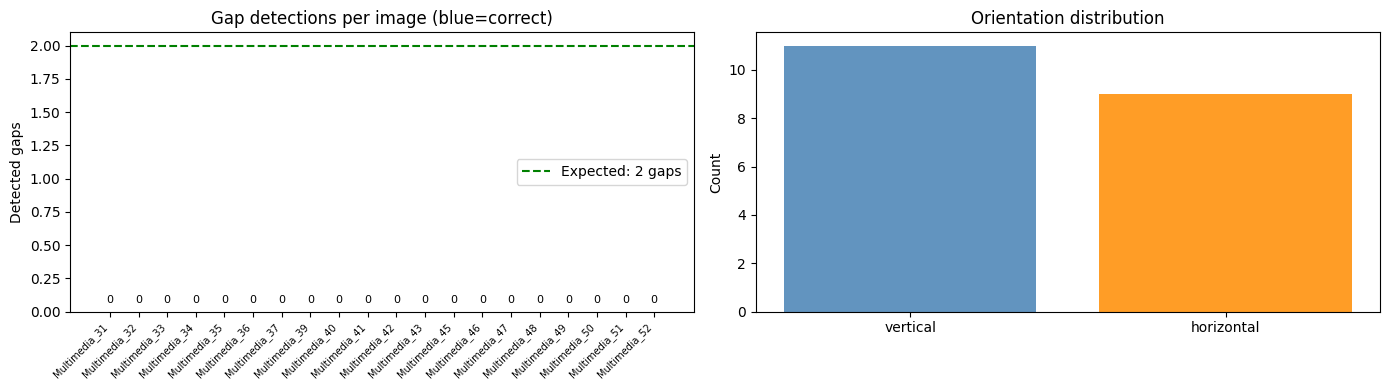

Correct (2 gaps): 0 / 20
Vertical       : 11
Horizontal     : 9


In [12]:
names   = list(hough_results.keys())
n_gaps  = [hough_results[n]['n_gaps'] for n in names]
orients = [hough_results[n]['orientation'] for n in names]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

bar_colors = ['steelblue' if n == 2 else 'tomato' for n in n_gaps]
axes[0].bar(range(len(names)), n_gaps, color=bar_colors, alpha=0.85)
for i, n in enumerate(n_gaps):
    axes[0].text(i, n + 0.05, str(n), ha='center', va='bottom', fontsize=8)
axes[0].axhline(2, color='green', linestyle='--', label='Expected: 2 gaps')
axes[0].set_xticks(range(len(names)))
axes[0].set_xticklabels([Path(n).stem for n in names], rotation=45, ha='right', fontsize=7)
axes[0].set_ylabel('Detected gaps')
axes[0].set_title('Gap detections per image (blue=correct)')
axes[0].legend()

orient_counts = {'vertical': orients.count('vertical'),
                 'horizontal': orients.count('horizontal')}
axes[1].bar(orient_counts.keys(), orient_counts.values(),
            color=['steelblue', 'darkorange'], alpha=0.85)
axes[1].set_title('Orientation distribution')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(DEBUG_DIR / 'detection_summary.png', dpi=150)
plt.show()

correct = sum(1 for n in n_gaps if n == 2)
print(f"Correct (2 gaps): {correct} / {len(names)}")
print(f"Vertical       : {orient_counts['vertical']}")
print(f"Horizontal     : {orient_counts['horizontal']}")

## 9. Summary

| Step | Operation | Detail |
|------|-----------|--------|
| 4a | Orientation detection | column vs row background variance |
| 4b | Gap detection | projection profile + width/length filters |
| 4c | Border extraction | Canny edge pixels within search window |
| 4d | Border fitting | median x/y per row/column |
| 4e | Sample points | 10 equally spaced points per border |

**Output folder:** `outputs/04_hough/`  
**Lines file:** `outputs/04_hough/lines.json`  
**Used by:** NB05, NB06  
**Next notebook:** `05_metric.ipynb`